# Réplication complète dans un notebook — Moskowitz, Hua Ooi & Pedersen (Time Series Momentum)

Ce notebook est autonome : il lit `data.xlsx`, nettoie les données, calcule les rendements mensuels, construit les signaux TSM, reproduit les figures clés et commente les résultats. Aucune sortie n'est écrite hors du notebook.

In [1]:
# Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from pathlib import Path
%matplotlib inline
sns.set(style='whitegrid')

## 1) Chargement et prétraitement des données (dans le notebook)
Nous lisons la feuille `data` de `data.xlsx`, convertissons la colonne `date` si nécessaire, et calculons les rendements mensuels.

In [2]:
# Chemin du fichier Excel (rechercher data.xlsx dans workspace)
p = Path('data.xlsx')
if not p.exists():
    p = Path('..') / 'data.xlsx'
    if not p.exists():
        raise FileNotFoundError('data.xlsx not found in workspace root or parent folder')
# Load sheet named 'data'
xl = pd.read_excel(p, sheet_name='data', engine='openpyxl')
print('Raw shape:', xl.shape)
# Convert Excel serial dates if numeric else parse strings
if 'date' not in xl.columns:
    raise KeyError('Expected a column named "date" in the sheet')
if pd.api.types.is_numeric_dtype(xl['date']):
    xl['date'] = pd.to_datetime(xl['date'], unit='D', origin='1899-12-30')
else:
    xl['date'] = pd.to_datetime(xl['date'], errors='coerce')
xl = xl.sort_values('date').set_index('date')
# Convert other columns to numeric (coerce errors)
price_df = xl.apply(pd.to_numeric, errors='coerce')
# Resample to month-end prices and compute monthly returns
monthly_prices = price_df.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna(how='all')
print('Monthly returns shape:', monthly_returns.shape)
display(monthly_returns.head())

Raw shape: (10697, 110)
Monthly returns shape: (491, 109)


,XP1 Index,CF1 Index,GX1 Index,ST1 Index,TP1 Index,EO1 Index,IB1 Index,Z 1 Index,SP1 Index,NDDLAS Index,...,USDCHF Curncy,SF0001M Index,GBPUSD Curncy,BP0001M Index,US0001M Index,MXWO Index,SPGSCI Index,LBUSTRUU Index,VIX Index,.TEDSP Index
date,,,,,,,,,,,,,,,,,,,,,
1985-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007481,0.023385,...,0.068037,NaN,-0.045555,NaN,0.042874,-0.000507,-0.028641,-0.020454,NaN,1.174208
1985-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008526,0.052275,...,-0.089954,NaN,0.145505,NaN,-0.013333,0.032189,0.051692,0.020387,NaN,-0.298647
1985-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013635,0.071236,...,0.000000,NaN,0.004045,NaN,-0.042793,-0.005214,-0.053243,0.020684,NaN,-0.151335
1985-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048659,0.001418,...,-0.009615,NaN,0.036261,NaN,-0.110294,0.048902,0.001067,0.052257,NaN,-0.435315
1985-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019773,-0.010473,...,-0.013204,NaN,0.018274,NaN,0.024793,0.015415,-0.040348,0.010572,NaN,1.699690


## 2) Fonctions utilitaires (EWMA, signaux TSM)
Définissons les fonctions nécessaires pour reproduire la stratégie: estimation de la volatilité ex-ante par EWMA, calcul du rendement passé k mois, génération de signaux et sizing.

In [3]:
def ewma_vol(returns, span=60):
    # EWMA monthly std, annualized
    return returns.ewm(span=span, adjust=False).std() * np.sqrt(12)

def past_k_return(returns, k):
    return returns.rolling(window=k).apply(lambda x: (1 + x).prod() - 1, raw=True)

def compute_tsm_strategy(returns, lookback=12, target_vol=0.40, vol_span=60):
    past = past_k_return(returns, lookback)
    vol = ewma_vol(returns, span=vol_span)
    signal = past.apply(np.sign)
    position_size = target_vol / vol
    position_size = position_size.replace([np.inf, -np.inf], np.nan)
    pos = (signal * position_size).shift(1)  # trade next period
    strat_ret = (pos * returns).mean(axis=1)
    return strat_ret, pos, past, vol

## 3) Reproduction de la Fig.1 — prédictibilité par horizon
Nous estimons pour chaque lag h la t-stat de la regression r_t ~ r_{t-h} (pooled mean across assets).

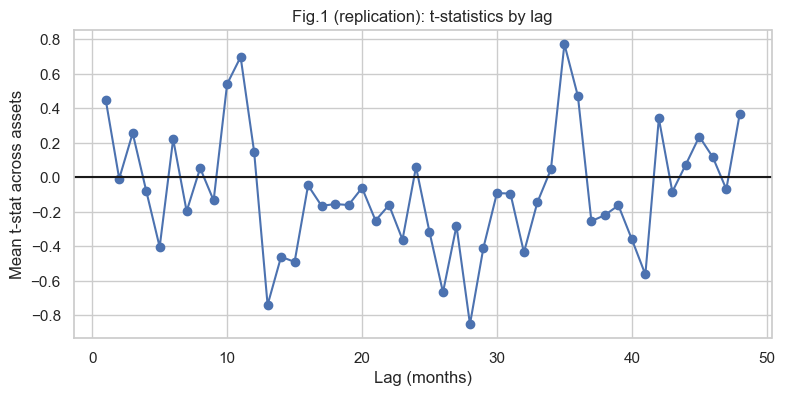

In [4]:
def tstats_by_lag(returns, max_lag=48):
    tstats = []
    for h in range(1, max_lag+1):
        tvals = []
        for col in returns.columns:
            s = returns[col].dropna()
            if len(s) <= h+24:
                continue
            y = s.iloc[h:].values
            x = s.iloc[:-h].values
            X = sm.add_constant(x)
            try:
                res = sm.OLS(y, X).fit(cov_type='HC1')
                tvals.append(res.tvalues[1])
            except Exception:
                continue
        tstats.append(np.nanmean(tvals) if tvals else np.nan)
    return np.array(tstats)

rets = monthly_returns.copy()
tstats = tstats_by_lag(rets, max_lag=48)
plt.figure(figsize=(9,4))
plt.plot(np.arange(1,len(tstats)+1), tstats, marker='o')
plt.axhline(0, color='k')
plt.xlabel('Lag (months)')
plt.ylabel('Mean t-stat across assets')
plt.title('Fig.1 (replication): t-statistics by lag')
plt.show()

**Commentaire:** on s'attend à des t-stats positifs pour les horizons 1–12 mois, puis à des signes négatifs à plus long terme, similaire à la Fig.1.

## 4) Fig.2 — Sharpe ratio par instrument (12m lookback, 1m hold)
Calcul du Sharpe annualisé par instrument pour la stratégie TSM aplicada par instrument (sizing 40% annual vol).

C:\Users\USER\AppData\Local\Temp\ipykernel_25524\4253750536.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sh.values, y=sh.index, palette='viridis')


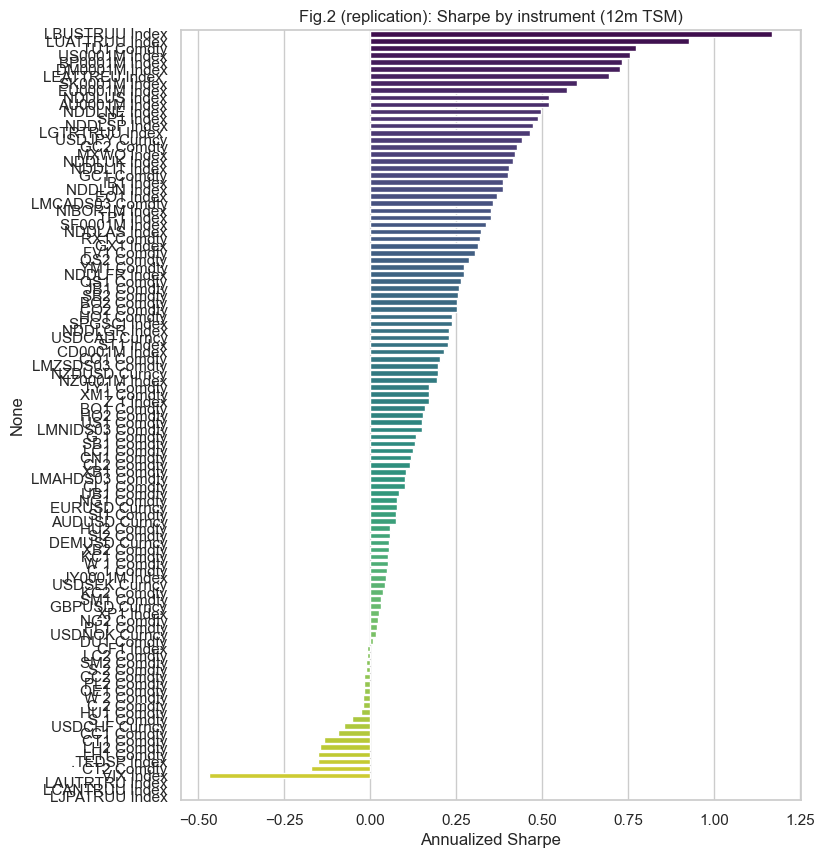

In [5]:
lookback = 12
past = past_k_return(rets, lookback)
vol = ewma_vol(rets, span=60)
signal = past.apply(np.sign)
pos = (signal * (0.40 / vol)).shift(1)
per_asset_ret = (pos * rets)
sharpe = {}
for col in per_asset_ret.columns:
    s = per_asset_ret[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 24:
        sharpe[col] = (s.mean()/s.std()) * np.sqrt(12)
    else:
        sharpe[col] = np.nan
sh = pd.Series(sharpe).sort_values(ascending=False)
plt.figure(figsize=(8,10))
sns.barplot(x=sh.values, y=sh.index, palette='viridis')
plt.xlabel('Annualized Sharpe')
plt.title('Fig.2 (replication): Sharpe by instrument (12m TSM)')
plt.show()

## 5) Fig.3 — cumulative returns du portefeuille diversifié TSMOM (12,1)
Construire le portefeuille diversifié (taille 40% annual vol par actif) et tracer la performance cumulée.

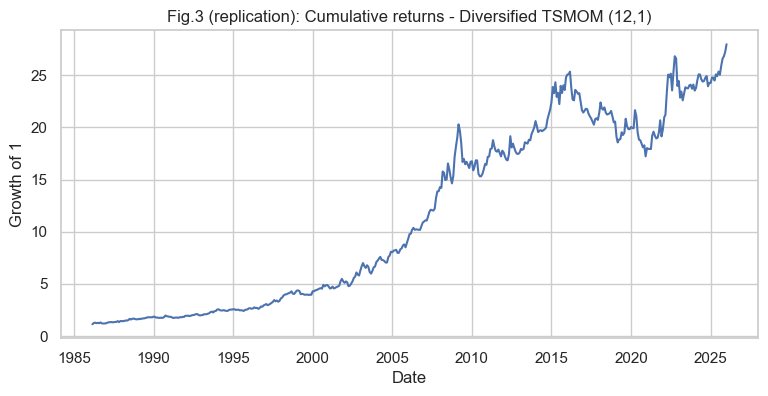

Annualized Sharpe (gross): 0.7751167624451235
Mean monthly ret: 0.007572902513383522
Std monthly ret: 0.03384432526673667


In [6]:
tsm_ret, pos, past, vol = compute_tsm_strategy(monthly_returns, lookback=12, target_vol=0.40, vol_span=60)
tsm_clean = tsm_ret.replace([np.inf, -np.inf], np.nan).dropna()
cum = (1 + tsm_clean).cumprod()
plt.figure(figsize=(9,4))
plt.plot(cum.index, cum.values)
plt.title('Fig.3 (replication): Cumulative returns - Diversified TSMOM (12,1)')
plt.ylabel('Growth of 1')
plt.xlabel('Date')
plt.grid(True)
plt.show()
# Summary metrics
print('Annualized Sharpe (gross):', (tsm_clean.mean()/tsm_clean.std()) * np.sqrt(12))
print('Mean monthly ret:', tsm_clean.mean())
print('Std monthly ret:', tsm_clean.std())

## 6) Régressions et analyses additionnelles
Exemples de regressions et pistes: reproduire Table 3 (regressions sur facteurs) et Table 5 (décomposition).

In [7]:
# Exemple: regression simple du facteur TSMOM sur un proxy 'market' (moyenne cross-assets)
market = monthly_returns.mean(axis=1)
Y = tsm_clean.values
X = sm.add_constant(market.loc[tsm_clean.index].values)
res = sm.OLS(Y, X).fit(cov_type='HC1')
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2162
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.642
Time:                        15:38:47   Log-Likelihood:                 938.99
No. Observations:                 477   AIC:                            -1874.
Df Residuals:                     475   BIC:                            -1866.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0073      0.002      4.574      0.0

## 7) Commentaires finaux
Interprétation: comparez les chiffres (Sharpe, formes des courbes) avec l'article; notez les différences possibles dues aux données/paramètres exacts ou au traitement des contrats futures vs. prix indices.